# Double Barrier Options: Interactive Analysis & Visualizations

**Product Type:** Path-Dependent Exotic Option  
**Key Feature:** Corridor-based survival/activation with upper AND lower barriers

---

## Table of Contents
1. [Setup & Imports](#1-setup--imports)
2. [Payoff Diagrams](#2-payoff-diagrams)
3. [Price Surfaces](#3-price-surfaces)
4. [Greeks Analysis](#4-greeks-analysis)
5. [In-Out Parity Verification](#5-in-out-parity-verification)
6. [Corridor Width Analysis](#6-corridor-width-analysis)
7. [Monte Carlo Analysis](#7-monte-carlo-analysis)
8. [Sample Paths Visualization](#8-sample-paths-visualization)

## 1. Setup & Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['legend.fontsize'] = 11

# Color scheme
COLORS = {
    'knock_out': '#2ecc71',    # Green
    'knock_in': '#e74c3c',     # Red
    'vanilla': '#3498db',      # Blue
    'single_barrier': '#f39c12', # Orange
    'survived': '#2ecc71',     # Green
    'knocked': '#e74c3c',      # Red
    'lower': '#9b59b6',        # Purple
    'upper': '#e67e22',        # Dark orange
    'path': '#3498db',         # Blue
}

In [2]:
# Base parameters for analysis
BASE_PARAMS = {
    'S0': 100.0,           # Initial spot price
    'K': 100.0,            # Strike price (ATM)
    'T': 1.0,              # Time to maturity (1 year)
    'r': 0.05,             # Domestic risk-free rate (5%)
    'q': 0.02,             # Foreign rate / dividend yield (2%)
    'sigma': 0.20,         # Volatility (20%)
    'lower_barrier': 85.0, # Lower barrier
    'upper_barrier': 115.0,# Upper barrier
}

# save figures
SAVE_FIGURES = False

print("Base Parameters:")
print("-" * 40)
for key, value in BASE_PARAMS.items():
    print(f"{key:18s}: {value}")
print(f"\nCorridor: [{BASE_PARAMS['lower_barrier']}, {BASE_PARAMS['upper_barrier']}]")
print(f"Corridor Width: {BASE_PARAMS['upper_barrier'] - BASE_PARAMS['lower_barrier']}")

Base Parameters:
----------------------------------------
S0                : 100.0
K                 : 100.0
T                 : 1.0
r                 : 0.05
q                 : 0.02
sigma             : 0.2
lower_barrier     : 85.0
upper_barrier     : 115.0

Corridor: [85.0, 115.0]
Corridor Width: 30.0


## Pricing Functions

In [3]:
def black_scholes_call(S, K, T, r, q, sigma):
    """Black-Scholes call option price."""
    if T <= 0:
        return max(S - K, 0)
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def black_scholes_put(S, K, T, r, q, sigma):
    """Black-Scholes put option price."""
    if T <= 0:
        return max(K - S, 0)
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)

def double_barrier_mc_price(S0, K, T, r, q, sigma, lower_barrier, upper_barrier,
                            barrier_style='knock_out', option_type='call',
                            rebate=0.0, n_paths=100000, n_steps=252, seed=42):
    """
    Monte Carlo pricer for double barrier options.
    
    Parameters
    ----------
    barrier_style : str
        'knock_out' (survives in corridor) or 'knock_in' (activates on exit)
    
    Returns
    -------
    tuple : (price, std_error, paths, exited_corridor)
    """
    np.random.seed(seed)
    
    # Validate corridor
    assert lower_barrier < S0 < upper_barrier, "S0 must be inside corridor"
    
    if T <= 0:
        if option_type == 'call':
            return max(S0 - K, 0), 0.0, None, None
        return max(K - S0, 0), 0.0, None, None
    
    dt = T / n_steps
    drift = (r - q - 0.5 * sigma**2) * dt
    diffusion = sigma * np.sqrt(dt)
    
    # Generate paths using antithetic variates
    Z = np.random.standard_normal((n_paths // 2, n_steps))
    Z = np.vstack([Z, -Z])  # Antithetic
    
    log_returns = drift + diffusion * Z
    log_paths = np.cumsum(log_returns, axis=1)
    
    # Include S0 in paths
    paths = np.column_stack([np.zeros(n_paths), log_paths])
    paths = S0 * np.exp(paths)
    
    # Check corridor exit
    max_spots = np.max(paths, axis=1)
    min_spots = np.min(paths, axis=1)
    
    hit_lower = min_spots <= lower_barrier
    hit_upper = max_spots >= upper_barrier
    exited_corridor = hit_lower | hit_upper
    
    terminal_spots = paths[:, -1]
    
    # Vanilla payoff
    if option_type == 'call':
        vanilla_payoff = np.maximum(terminal_spots - K, 0)
    else:
        vanilla_payoff = np.maximum(K - terminal_spots, 0)
    
    # Apply barrier logic
    if barrier_style == 'knock_out':
        # Pays vanilla if stayed in corridor
        payoffs = np.where(~exited_corridor, vanilla_payoff, rebate)
    else:  # knock_in
        # Pays vanilla if exited corridor
        payoffs = np.where(exited_corridor, vanilla_payoff, rebate)
    
    # Discount
    discounted = np.exp(-r * T) * payoffs
    price = np.mean(discounted)
    std_error = np.std(discounted) / np.sqrt(n_paths)
    
    return price, std_error, paths, exited_corridor

## 2. Payoff Diagrams

Visualizing the payoff structure for double barrier options.

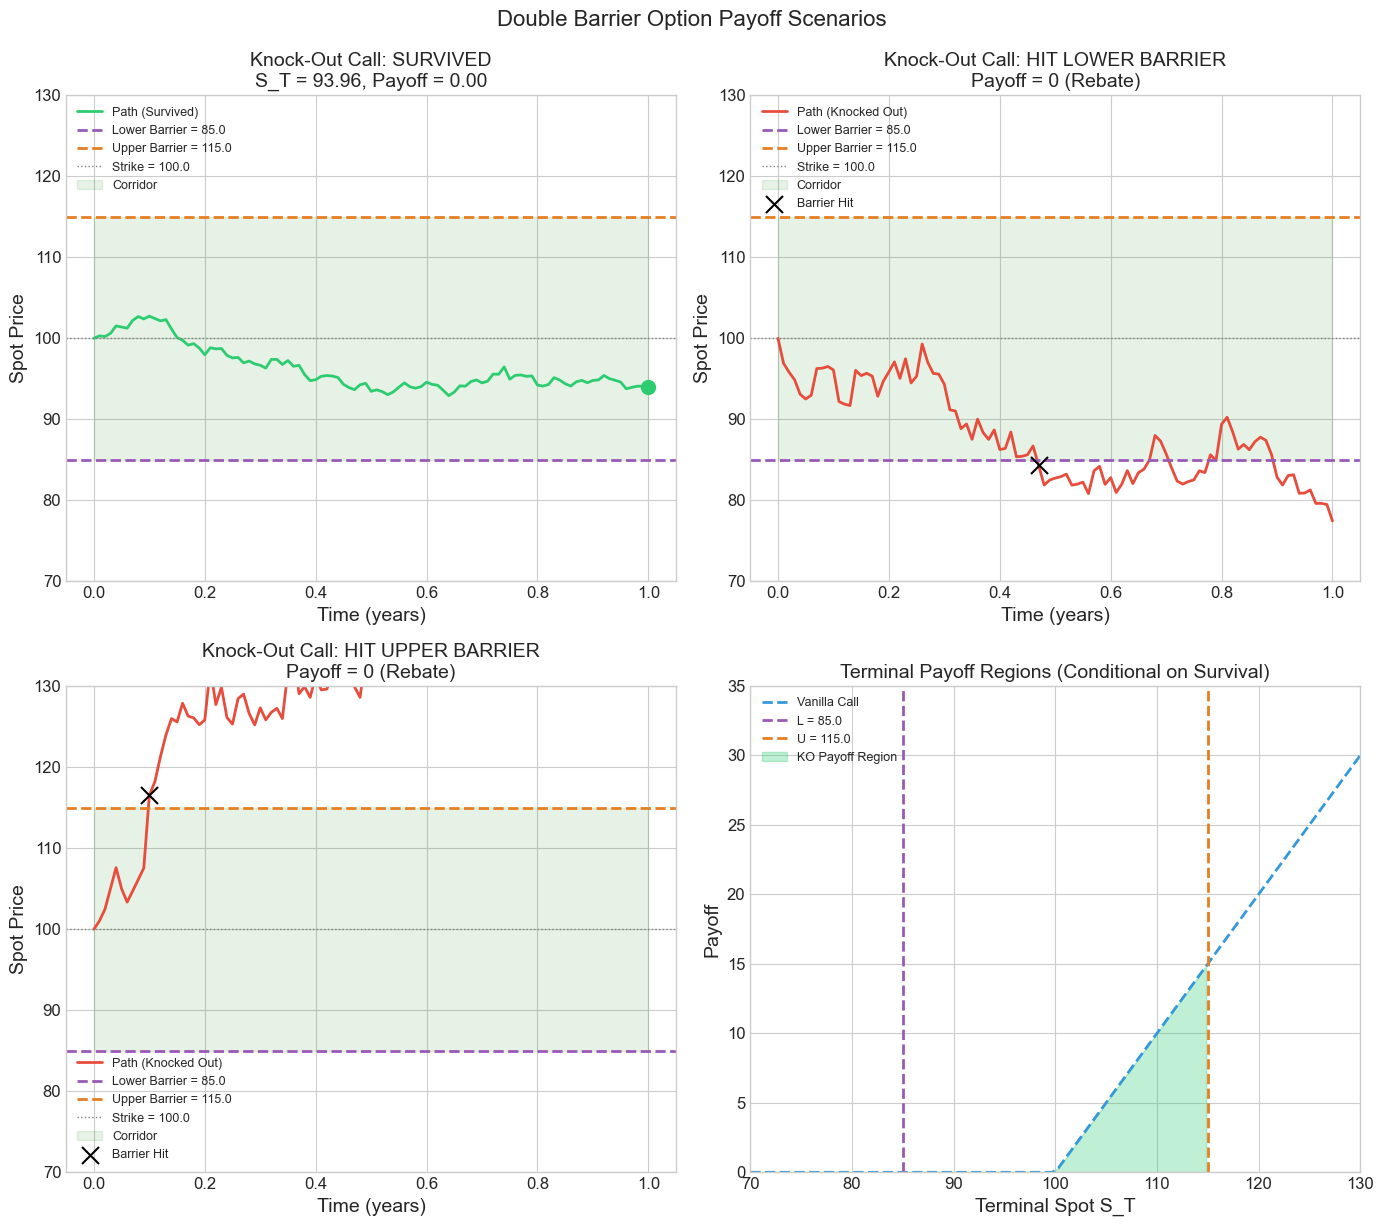

In [4]:
# Generate sample paths to illustrate payoffs
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

S0 = BASE_PARAMS['S0']
K = BASE_PARAMS['K']
L = BASE_PARAMS['lower_barrier']
U = BASE_PARAMS['upper_barrier']

# Generate example paths
np.random.seed(42)
n_steps = 100
dt = 1.0 / n_steps
t = np.linspace(0, 1, n_steps + 1)

# Path that survives (stays in corridor)
Z_survive = np.random.randn(n_steps) * 0.3
path_survive = S0 * np.exp(np.cumsum(np.insert(Z_survive * np.sqrt(dt) * 0.2, 0, 0)))

# Path that hits lower barrier
Z_lower = np.random.randn(n_steps) - 0.15
path_lower = S0 * np.exp(np.cumsum(np.insert(Z_lower * np.sqrt(dt) * 0.2, 0, 0)))

# Path that hits upper barrier
Z_upper = np.random.randn(n_steps) + 0.15
path_upper = S0 * np.exp(np.cumsum(np.insert(Z_upper * np.sqrt(dt) * 0.2, 0, 0)))

# Ax 0: Knock-Out Call - Survived
ax = axes[0, 0]
ax.plot(t, path_survive, color=COLORS['survived'], linewidth=2, label='Path (Survived)')
ax.axhline(y=L, color=COLORS['lower'], linestyle='--', linewidth=2, label=f'Lower Barrier = {L}')
ax.axhline(y=U, color=COLORS['upper'], linestyle='--', linewidth=2, label=f'Upper Barrier = {U}')
ax.axhline(y=K, color='gray', linestyle=':', linewidth=1, label=f'Strike = {K}')
ax.fill_between(t, L, U, alpha=0.1, color='green', label='Corridor')
S_T = path_survive[-1]
payoff = max(S_T - K, 0)
ax.scatter([1], [S_T], s=100, c=COLORS['survived'], zorder=5)
ax.set_title(f'Knock-Out Call: SURVIVED\nS_T = {S_T:.2f}, Payoff = {payoff:.2f}', fontsize=14)
ax.set_xlabel('Time (years)')
ax.set_ylabel('Spot Price')
ax.legend(loc='upper left', fontsize=9)
ax.set_ylim([70, 130])

# Ax 1: Knock-Out Call - Hit Lower
ax = axes[0, 1]
ax.plot(t, path_lower, color=COLORS['knocked'], linewidth=2, label='Path (Knocked Out)')
ax.axhline(y=L, color=COLORS['lower'], linestyle='--', linewidth=2, label=f'Lower Barrier = {L}')
ax.axhline(y=U, color=COLORS['upper'], linestyle='--', linewidth=2, label=f'Upper Barrier = {U}')
ax.axhline(y=K, color='gray', linestyle=':', linewidth=1, label=f'Strike = {K}')
ax.fill_between(t, L, U, alpha=0.1, color='green', label='Corridor')
hit_idx = np.where(path_lower <= L)[0][0] if np.any(path_lower <= L) else -1
if hit_idx > 0:
    ax.scatter([t[hit_idx]], [path_lower[hit_idx]], s=150, c='black', marker='x', zorder=5, label='Barrier Hit')
ax.set_title(f'Knock-Out Call: HIT LOWER BARRIER\nPayoff = 0 (Rebate)', fontsize=14)
ax.set_xlabel('Time (years)')
ax.set_ylabel('Spot Price')
ax.legend(loc='upper left', fontsize=9)
ax.set_ylim([70, 130])

# Ax 2: Knock-Out Call - Hit Upper
ax = axes[1, 0]
ax.plot(t, path_upper, color=COLORS['knocked'], linewidth=2, label='Path (Knocked Out)')
ax.axhline(y=L, color=COLORS['lower'], linestyle='--', linewidth=2, label=f'Lower Barrier = {L}')
ax.axhline(y=U, color=COLORS['upper'], linestyle='--', linewidth=2, label=f'Upper Barrier = {U}')
ax.axhline(y=K, color='gray', linestyle=':', linewidth=1, label=f'Strike = {K}')
ax.fill_between(t, L, U, alpha=0.1, color='green', label='Corridor')
hit_idx = np.where(path_upper >= U)[0][0] if np.any(path_upper >= U) else -1
if hit_idx > 0:
    ax.scatter([t[hit_idx]], [path_upper[hit_idx]], s=150, c='black', marker='x', zorder=5, label='Barrier Hit')
ax.set_title(f'Knock-Out Call: HIT UPPER BARRIER\nPayoff = 0 (Rebate)', fontsize=14)
ax.set_xlabel('Time (years)')
ax.set_ylabel('Spot Price')
ax.legend(loc='lower left', fontsize=9)
ax.set_ylim([70, 130])

# Ax 3: Payoff Diagram at Terminal
ax = axes[1, 1]
S_range = np.linspace(70, 130, 100)
vanilla_call = np.maximum(S_range - K, 0)

# For KO: pays vanilla if survived
# Illustrate with final spot distribution
ax.plot(S_range, vanilla_call, color=COLORS['vanilla'], linewidth=2, linestyle='--', label='Vanilla Call')
ax.axvline(x=L, color=COLORS['lower'], linestyle='--', linewidth=2, label=f'L = {L}')
ax.axvline(x=U, color=COLORS['upper'], linestyle='--', linewidth=2, label=f'U = {U}')

# KO payoff (only pays if S_T is in corridor AND path stayed in corridor)
ko_region = (S_range >= L) & (S_range <= U)
ax.fill_between(S_range, 0, vanilla_call, where=ko_region, alpha=0.3, color=COLORS['knock_out'], label='KO Payoff Region')
ax.set_title('Terminal Payoff Regions (Conditional on Survival)', fontsize=14)
ax.set_xlabel('Terminal Spot S_T')
ax.set_ylabel('Payoff')
ax.legend(loc='upper left', fontsize=9)
ax.set_xlim([70, 130])
ax.set_ylim([0, 35])

plt.tight_layout()
plt.suptitle('Double Barrier Option Payoff Scenarios', fontsize=16, y=1.02)
plt.show()

## 3. Price Surfaces

Visualizing how double barrier option prices vary with spot and volatility.

In [5]:
# Generate price surfaces
spots = np.linspace(87, 113, 20)  # Stay inside corridor
vols = np.linspace(0.10, 0.40, 20)
S_grid, vol_grid = np.meshgrid(spots, vols)

# Calculate prices for knock-out and vanilla
ko_prices = np.zeros_like(S_grid)
vanilla_prices = np.zeros_like(S_grid)

print("Computing price surfaces (this may take a moment)...")
for i in range(len(vols)):
    for j in range(len(spots)):
        S = spots[j]
        sigma = vols[i]
        
        ko_prices[i, j], _, _, _ = double_barrier_mc_price(
            S, BASE_PARAMS['K'], BASE_PARAMS['T'],
            BASE_PARAMS['r'], BASE_PARAMS['q'], sigma,
            BASE_PARAMS['lower_barrier'], BASE_PARAMS['upper_barrier'],
            barrier_style='knock_out', n_paths=20000, n_steps=100
        )
        vanilla_prices[i, j] = black_scholes_call(
            S, BASE_PARAMS['K'], BASE_PARAMS['T'],
            BASE_PARAMS['r'], BASE_PARAMS['q'], sigma
        )

print("Done!")

Computing price surfaces (this may take a moment)...
Done!


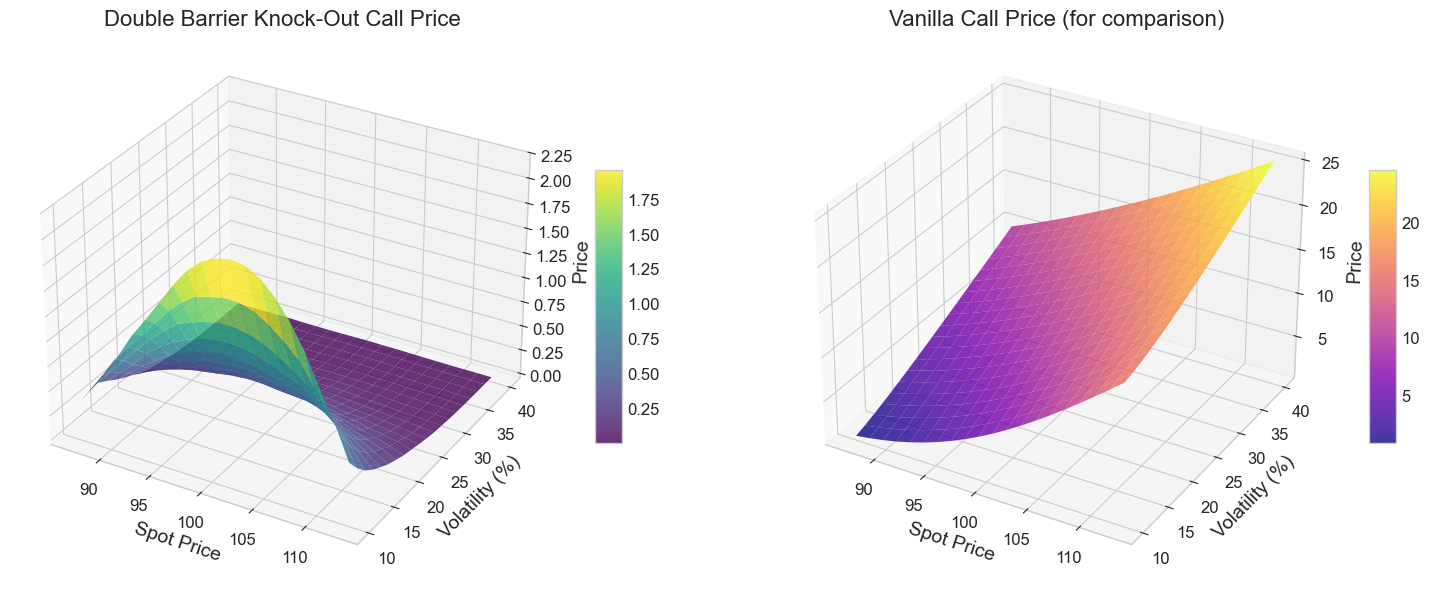

In [6]:
# Plot 3D surfaces
fig = plt.figure(figsize=(16, 6))

# Knock-Out surface
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(S_grid, vol_grid * 100, ko_prices, cmap=cm.viridis, alpha=0.8)
ax1.set_xlabel('Spot Price')
ax1.set_ylabel('Volatility (%)')
ax1.set_zlabel('Price')
ax1.set_title('Double Barrier Knock-Out Call Price')
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)

# Vanilla surface for comparison
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(S_grid, vol_grid * 100, vanilla_prices, cmap=cm.plasma, alpha=0.8)
ax2.set_xlabel('Spot Price')
ax2.set_ylabel('Volatility (%)')
ax2.set_zlabel('Price')
ax2.set_title('Vanilla Call Price (for comparison)')
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10)

plt.tight_layout()
plt.show()

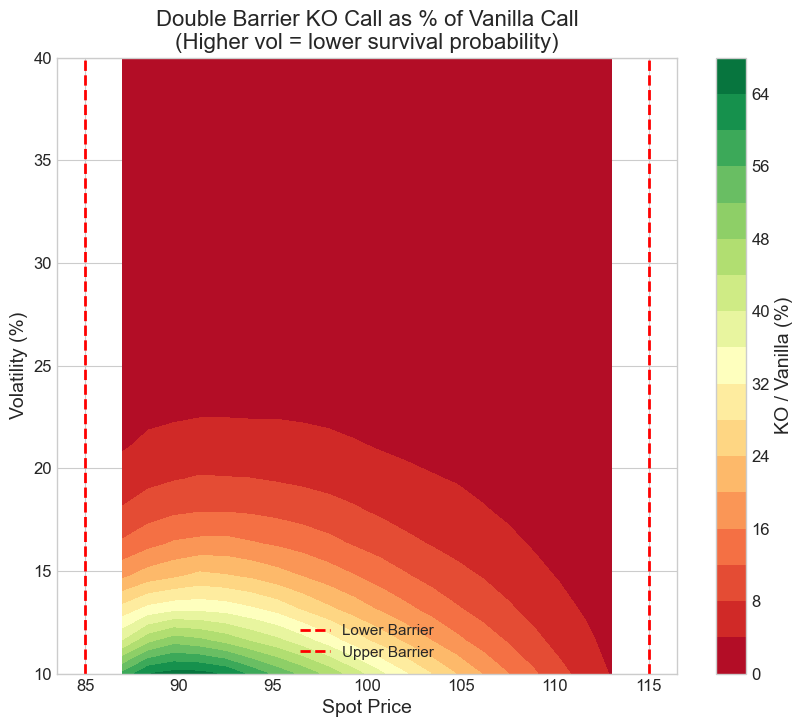

In [7]:
# Price ratio: Double Barrier / Vanilla
fig, ax = plt.subplots(figsize=(10, 8))

price_ratio = ko_prices / np.maximum(vanilla_prices, 0.01)
contour = ax.contourf(S_grid, vol_grid * 100, price_ratio * 100, levels=20, cmap=cm.RdYlGn)
plt.colorbar(contour, ax=ax, label='KO / Vanilla (%)')

ax.axvline(x=BASE_PARAMS['lower_barrier'], color='red', linestyle='--', linewidth=2, label='Lower Barrier')
ax.axvline(x=BASE_PARAMS['upper_barrier'], color='red', linestyle='--', linewidth=2, label='Upper Barrier')

ax.set_xlabel('Spot Price')
ax.set_ylabel('Volatility (%)')
ax.set_title('Double Barrier KO Call as % of Vanilla Call\n(Higher vol = lower survival probability)')
ax.legend()
plt.show()

## 4. Greeks Analysis

Examining Delta, Gamma, and Vega for double barrier options.

In [8]:
def compute_greeks_fd(S0, K, T, r, q, sigma, L, U, barrier_style='knock_out', 
                      option_type='call', n_paths=50000):
    """Compute Greeks using finite differences."""
    dS = 0.5
    dsigma = 0.005
    
    # Base price
    V0, _, _, _ = double_barrier_mc_price(S0, K, T, r, q, sigma, L, U, 
                                          barrier_style, option_type, n_paths=n_paths)
    
    # Delta
    V_up, _, _, _ = double_barrier_mc_price(S0 + dS, K, T, r, q, sigma, L, U,
                                             barrier_style, option_type, n_paths=n_paths)
    V_down, _, _, _ = double_barrier_mc_price(S0 - dS, K, T, r, q, sigma, L, U,
                                               barrier_style, option_type, n_paths=n_paths)
    delta = (V_up - V_down) / (2 * dS)
    gamma = (V_up - 2*V0 + V_down) / (dS**2)
    
    # Vega
    V_sigma_up, _, _, _ = double_barrier_mc_price(S0, K, T, r, q, sigma + dsigma, L, U,
                                                   barrier_style, option_type, n_paths=n_paths)
    vega = (V_sigma_up - V0) / dsigma * 0.01  # per 1% vol change
    
    return {'delta': delta, 'gamma': gamma, 'vega': vega, 'price': V0}

In [9]:
# Compute Greeks across spot range
spots_for_greeks = np.linspace(87, 113, 25)
ko_deltas = []
ko_gammas = []
ko_vegas = []
vanilla_deltas = []

print("Computing Greeks...")
for S in spots_for_greeks:
    greeks = compute_greeks_fd(S, BASE_PARAMS['K'], BASE_PARAMS['T'],
                               BASE_PARAMS['r'], BASE_PARAMS['q'], BASE_PARAMS['sigma'],
                               BASE_PARAMS['lower_barrier'], BASE_PARAMS['upper_barrier'],
                               n_paths=30000)
    ko_deltas.append(greeks['delta'])
    ko_gammas.append(greeks['gamma'])
    ko_vegas.append(greeks['vega'])
    
    # Vanilla delta for comparison
    d1 = (np.log(S / BASE_PARAMS['K']) + (BASE_PARAMS['r'] - BASE_PARAMS['q'] + 0.5 * BASE_PARAMS['sigma']**2) * BASE_PARAMS['T']) / (BASE_PARAMS['sigma'] * np.sqrt(BASE_PARAMS['T']))
    vanilla_deltas.append(np.exp(-BASE_PARAMS['q'] * BASE_PARAMS['T']) * norm.cdf(d1))

print("Done!")

Computing Greeks...
Done!


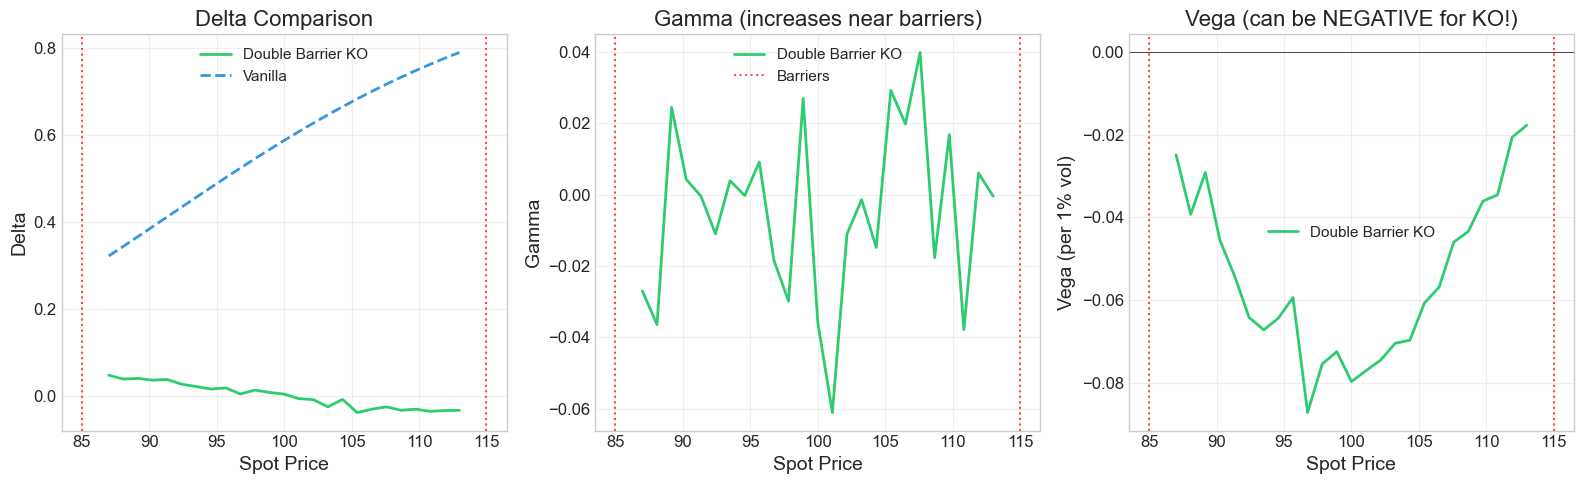

In [10]:
# Plot Greeks
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Delta
ax = axes[0]
ax.plot(spots_for_greeks, ko_deltas, color=COLORS['knock_out'], linewidth=2, label='Double Barrier KO')
ax.plot(spots_for_greeks, vanilla_deltas, color=COLORS['vanilla'], linewidth=2, linestyle='--', label='Vanilla')
ax.axvline(x=BASE_PARAMS['lower_barrier'], color='red', linestyle=':', alpha=0.7)
ax.axvline(x=BASE_PARAMS['upper_barrier'], color='red', linestyle=':', alpha=0.7)
ax.set_xlabel('Spot Price')
ax.set_ylabel('Delta')
ax.set_title('Delta Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

# Gamma
ax = axes[1]
ax.plot(spots_for_greeks, ko_gammas, color=COLORS['knock_out'], linewidth=2, label='Double Barrier KO')
ax.axvline(x=BASE_PARAMS['lower_barrier'], color='red', linestyle=':', alpha=0.7, label='Barriers')
ax.axvline(x=BASE_PARAMS['upper_barrier'], color='red', linestyle=':', alpha=0.7)
ax.set_xlabel('Spot Price')
ax.set_ylabel('Gamma')
ax.set_title('Gamma (increases near barriers)')
ax.legend()
ax.grid(True, alpha=0.3)

# Vega
ax = axes[2]
ax.plot(spots_for_greeks, ko_vegas, color=COLORS['knock_out'], linewidth=2, label='Double Barrier KO')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.axvline(x=BASE_PARAMS['lower_barrier'], color='red', linestyle=':', alpha=0.7)
ax.axvline(x=BASE_PARAMS['upper_barrier'], color='red', linestyle=':', alpha=0.7)
ax.set_xlabel('Spot Price')
ax.set_ylabel('Vega (per 1% vol)')
ax.set_title('Vega (can be NEGATIVE for KO!)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. In-Out Parity Verification

Verifying that KO + KI = Vanilla (with zero rebate).

In [11]:
# Verify In-Out Parity: V_KO + V_KI = V_Vanilla
spots_parity = np.linspace(87, 113, 15)
ko_prices_parity = []
ki_prices_parity = []
vanilla_prices_parity = []

print("Verifying In-Out Parity...")
for S in spots_parity:
    ko, _, _, _ = double_barrier_mc_price(
        S, BASE_PARAMS['K'], BASE_PARAMS['T'],
        BASE_PARAMS['r'], BASE_PARAMS['q'], BASE_PARAMS['sigma'],
        BASE_PARAMS['lower_barrier'], BASE_PARAMS['upper_barrier'],
        barrier_style='knock_out', rebate=0.0, n_paths=50000
    )
    ki, _, _, _ = double_barrier_mc_price(
        S, BASE_PARAMS['K'], BASE_PARAMS['T'],
        BASE_PARAMS['r'], BASE_PARAMS['q'], BASE_PARAMS['sigma'],
        BASE_PARAMS['lower_barrier'], BASE_PARAMS['upper_barrier'],
        barrier_style='knock_in', rebate=0.0, n_paths=50000
    )
    vanilla = black_scholes_call(
        S, BASE_PARAMS['K'], BASE_PARAMS['T'],
        BASE_PARAMS['r'], BASE_PARAMS['q'], BASE_PARAMS['sigma']
    )
    
    ko_prices_parity.append(ko)
    ki_prices_parity.append(ki)
    vanilla_prices_parity.append(vanilla)

print("Done!")

Verifying In-Out Parity...
Done!


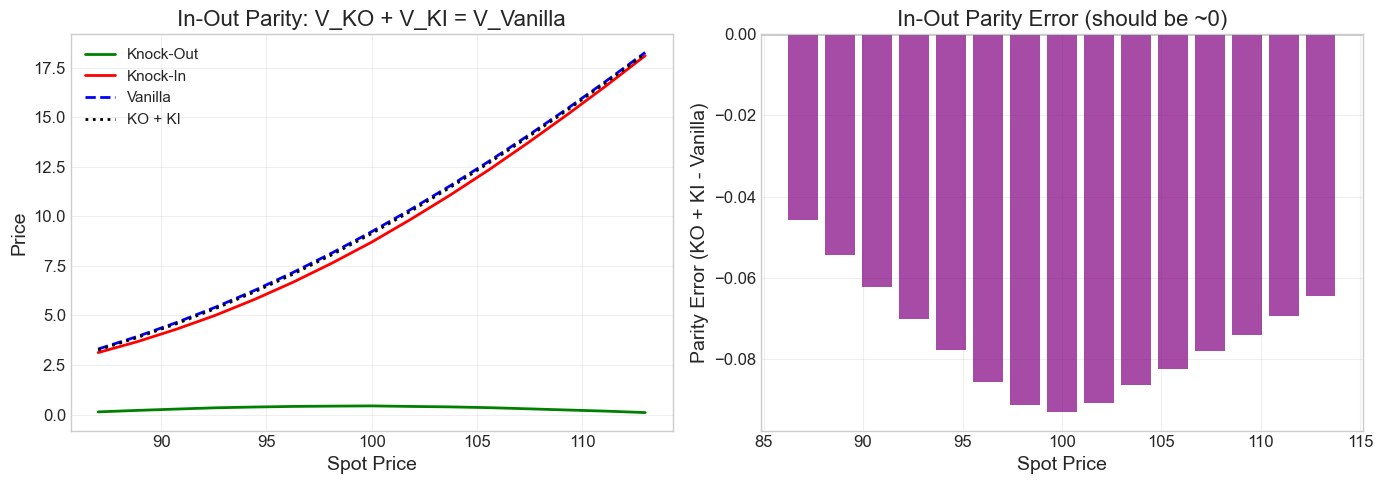


Mean Absolute Parity Error: 0.0752
Max Absolute Parity Error: 0.0931


In [12]:
# Plot In-Out Parity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prices
ax = axes[0]
ax.plot(spots_parity, ko_prices_parity, 'g-', linewidth=2, label='Knock-Out')
ax.plot(spots_parity, ki_prices_parity, 'r-', linewidth=2, label='Knock-In')
ax.plot(spots_parity, vanilla_prices_parity, 'b--', linewidth=2, label='Vanilla')
ax.plot(spots_parity, np.array(ko_prices_parity) + np.array(ki_prices_parity), 'k:', linewidth=2, label='KO + KI')
ax.set_xlabel('Spot Price')
ax.set_ylabel('Price')
ax.set_title('In-Out Parity: V_KO + V_KI = V_Vanilla')
ax.legend()
ax.grid(True, alpha=0.3)

# Parity Error
ax = axes[1]
parity_error = np.array(ko_prices_parity) + np.array(ki_prices_parity) - np.array(vanilla_prices_parity)
ax.bar(spots_parity, parity_error, width=1.5, color='purple', alpha=0.7)
ax.axhline(y=0, color='black', linewidth=1)
ax.set_xlabel('Spot Price')
ax.set_ylabel('Parity Error (KO + KI - Vanilla)')
ax.set_title('In-Out Parity Error (should be ~0)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nMean Absolute Parity Error: {np.mean(np.abs(parity_error)):.4f}")
print(f"Max Absolute Parity Error: {np.max(np.abs(parity_error)):.4f}")

## 6. Corridor Width Analysis

Examining how corridor width affects prices.

In [13]:
# Analyze effect of corridor width
corridor_widths = [10, 15, 20, 25, 30, 40]  # Total width (symmetric around S0)
ko_by_width = []
survival_probs = []

S0 = BASE_PARAMS['S0']

print("Analyzing corridor width effect...")
for width in corridor_widths:
    L = S0 - width / 2
    U = S0 + width / 2
    
    ko, _, paths, exited = double_barrier_mc_price(
        S0, BASE_PARAMS['K'], BASE_PARAMS['T'],
        BASE_PARAMS['r'], BASE_PARAMS['q'], BASE_PARAMS['sigma'],
        L, U, barrier_style='knock_out', n_paths=50000
    )
    ko_by_width.append(ko)
    survival_probs.append(1 - np.mean(exited))

print("Done!")

Analyzing corridor width effect...
Done!


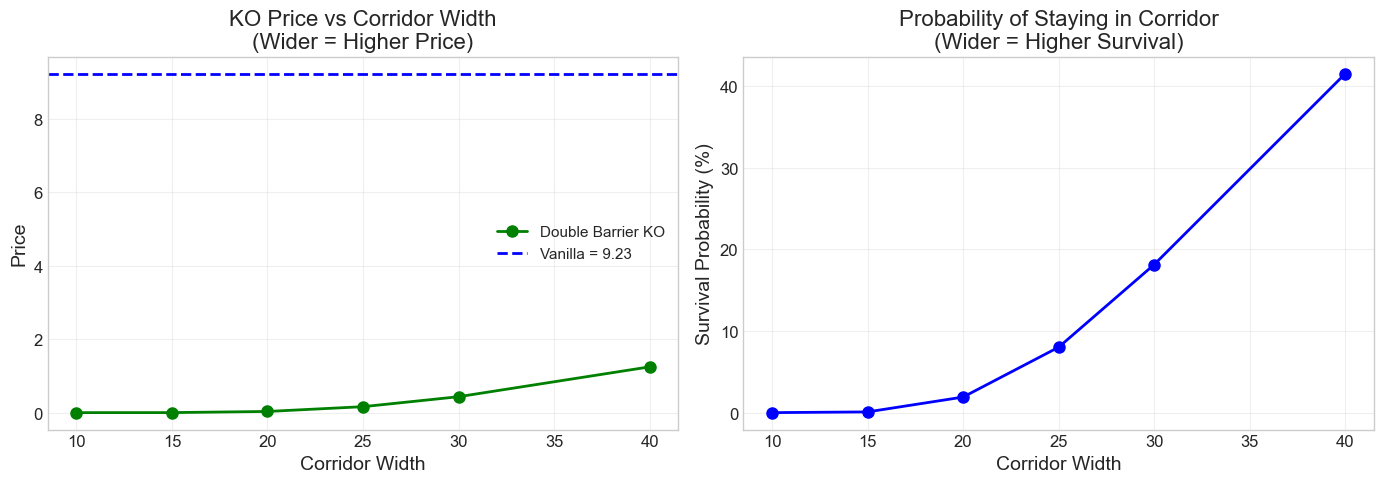

In [14]:
# Plot corridor width analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vanilla_price = black_scholes_call(
    S0, BASE_PARAMS['K'], BASE_PARAMS['T'],
    BASE_PARAMS['r'], BASE_PARAMS['q'], BASE_PARAMS['sigma']
)

# Prices
ax = axes[0]
ax.plot(corridor_widths, ko_by_width, 'go-', linewidth=2, markersize=8, label='Double Barrier KO')
ax.axhline(y=vanilla_price, color='blue', linestyle='--', linewidth=2, label=f'Vanilla = {vanilla_price:.2f}')
ax.set_xlabel('Corridor Width')
ax.set_ylabel('Price')
ax.set_title('KO Price vs Corridor Width\n(Wider = Higher Price)')
ax.legend()
ax.grid(True, alpha=0.3)

# Survival Probability
ax = axes[1]
ax.plot(corridor_widths, np.array(survival_probs) * 100, 'bo-', linewidth=2, markersize=8)
ax.set_xlabel('Corridor Width')
ax.set_ylabel('Survival Probability (%)')
ax.set_title('Probability of Staying in Corridor\n(Wider = Higher Survival)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Monte Carlo Analysis

Convergence and confidence intervals.

NameError: name 'path_counts' is not defined

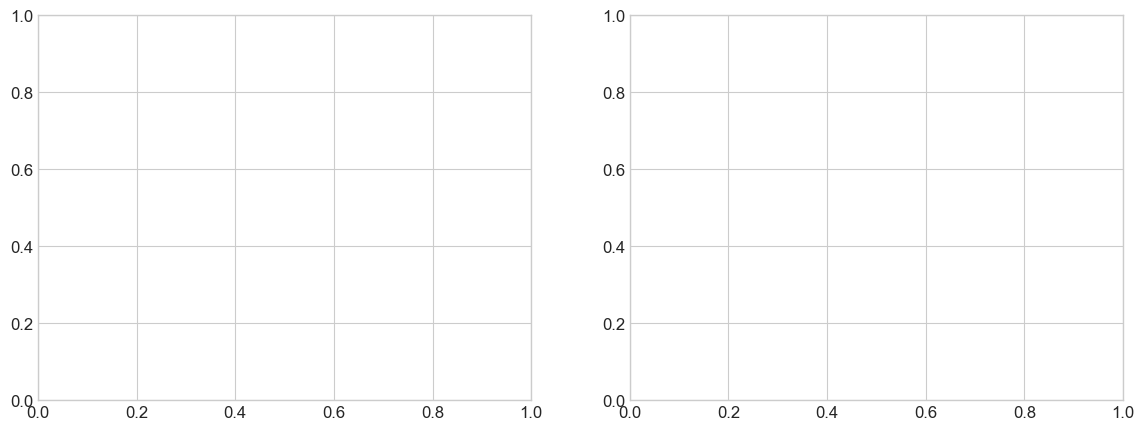

In [15]:
# Plot convergence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Price convergence
ax = axes[0]
ax.errorbar(path_counts, prices, yerr=1.96*np.array(std_errors), 
            fmt='go-', capsize=5, linewidth=2, markersize=8, label='MC Price ± 95% CI')
ax.axhline(y=prices[-1], color='red', linestyle='--', alpha=0.7, label=f'Reference = {prices[-1]:.4f}')
ax.set_xlabel('Number of Paths')
ax.set_ylabel('Price')
ax.set_title('Monte Carlo Convergence')
ax.set_xscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

# Standard error vs sqrt(n)
ax = axes[1]
ax.loglog(path_counts, std_errors, 'bo-', linewidth=2, markersize=8, label='Actual Std Error')
theoretical = std_errors[0] * np.sqrt(path_counts[0]) / np.sqrt(path_counts)
ax.loglog(path_counts, theoretical, 'r--', linewidth=2, label='Theoretical O(1/√n)')
ax.set_xlabel('Number of Paths')
ax.set_ylabel('Standard Error')
ax.set_title('Standard Error Convergence')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Sample Paths Visualization

Visualizing paths that survive vs paths that exit the corridor.

In [ ]:
# Generate paths for visualization
_, _, all_paths, exited = double_barrier_mc_price(
    BASE_PARAMS['S0'], BASE_PARAMS['K'], BASE_PARAMS['T'],
    BASE_PARAMS['r'], BASE_PARAMS['q'], BASE_PARAMS['sigma'],
    BASE_PARAMS['lower_barrier'], BASE_PARAMS['upper_barrier'],
    barrier_style='knock_out', n_paths=1000, n_steps=252, seed=123
)

# Plot sample paths
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

t = np.linspace(0, 1, all_paths.shape[1])

# Survived paths
ax = axes[0]
survived_paths = all_paths[~exited]
for i in range(min(50, len(survived_paths))):
    ax.plot(t, survived_paths[i], color=COLORS['survived'], alpha=0.3, linewidth=0.5)
ax.axhline(y=BASE_PARAMS['lower_barrier'], color='red', linestyle='--', linewidth=2, label='Barriers')
ax.axhline(y=BASE_PARAMS['upper_barrier'], color='red', linestyle='--', linewidth=2)
ax.fill_between(t, BASE_PARAMS['lower_barrier'], BASE_PARAMS['upper_barrier'], alpha=0.1, color='green')
ax.set_xlabel('Time (years)')
ax.set_ylabel('Spot Price')
ax.set_title(f'SURVIVED Paths ({np.sum(~exited)} / {len(exited)} = {100*np.mean(~exited):.1f}%)')
ax.legend()
ax.set_ylim([70, 130])

# Knocked-out paths
ax = axes[1]
knocked_paths = all_paths[exited]
for i in range(min(50, len(knocked_paths))):
    ax.plot(t, knocked_paths[i], color=COLORS['knocked'], alpha=0.3, linewidth=0.5)
ax.axhline(y=BASE_PARAMS['lower_barrier'], color='red', linestyle='--', linewidth=2, label='Barriers')
ax.axhline(y=BASE_PARAMS['upper_barrier'], color='red', linestyle='--', linewidth=2)
ax.fill_between(t, BASE_PARAMS['lower_barrier'], BASE_PARAMS['upper_barrier'], alpha=0.1, color='green')
ax.set_xlabel('Time (years)')
ax.set_ylabel('Spot Price')
ax.set_title(f'KNOCKED-OUT Paths ({np.sum(exited)} / {len(exited)} = {100*np.mean(exited):.1f}%)')
ax.legend()
ax.set_ylim([70, 130])

plt.tight_layout()
plt.show()

## Summary Statistics

In [ ]:
# Final summary
print("="*60)
print("DOUBLE BARRIER OPTION ANALYSIS SUMMARY")
print("="*60)

ko_price, ko_se, _, exited_final = double_barrier_mc_price(
    BASE_PARAMS['S0'], BASE_PARAMS['K'], BASE_PARAMS['T'],
    BASE_PARAMS['r'], BASE_PARAMS['q'], BASE_PARAMS['sigma'],
    BASE_PARAMS['lower_barrier'], BASE_PARAMS['upper_barrier'],
    barrier_style='knock_out', n_paths=200000
)

ki_price, ki_se, _, _ = double_barrier_mc_price(
    BASE_PARAMS['S0'], BASE_PARAMS['K'], BASE_PARAMS['T'],
    BASE_PARAMS['r'], BASE_PARAMS['q'], BASE_PARAMS['sigma'],
    BASE_PARAMS['lower_barrier'], BASE_PARAMS['upper_barrier'],
    barrier_style='knock_in', n_paths=200000
)

vanilla = black_scholes_call(
    BASE_PARAMS['S0'], BASE_PARAMS['K'], BASE_PARAMS['T'],
    BASE_PARAMS['r'], BASE_PARAMS['q'], BASE_PARAMS['sigma']
)

print(f"\nParameters:")
print(f"  Spot: {BASE_PARAMS['S0']}, Strike: {BASE_PARAMS['K']}")
print(f"  Lower Barrier: {BASE_PARAMS['lower_barrier']}, Upper Barrier: {BASE_PARAMS['upper_barrier']}")
print(f"  Corridor Width: {BASE_PARAMS['upper_barrier'] - BASE_PARAMS['lower_barrier']}")
print(f"  Volatility: {BASE_PARAMS['sigma']*100}%, Time: {BASE_PARAMS['T']} year")

print(f"\nPrices:")
print(f"  Vanilla Call:         {vanilla:.4f}")
print(f"  Double Barrier KO:    {ko_price:.4f} ± {1.96*ko_se:.4f}")
print(f"  Double Barrier KI:    {ki_price:.4f} ± {1.96*ki_se:.4f}")
print(f"  KO + KI:              {ko_price + ki_price:.4f}")
print(f"  Parity Error:         {ko_price + ki_price - vanilla:.4f}")

print(f"\nProbabilities:")
print(f"  Survival Probability: {100*(1-np.mean(exited_final)):.2f}%")
print(f"  Exit Probability:     {100*np.mean(exited_final):.2f}%")

print(f"\nKey Insights:")
print(f"  - KO/Vanilla Ratio:   {100*ko_price/vanilla:.1f}%")
print(f"  - Double barrier KO is {100*(1-ko_price/vanilla):.1f}% cheaper than vanilla")